[![Open In Colab](https://colab.research.google.com/assets/colab-badge.svg)](
https://colab.research.google.com/github/AnirbanKopty/GWFC_DAT/blob/main/Session1/Tutorial/02_Estimate_PSD.ipynb)

# Tutorial 2: Estimate PSD from Data
In this notebook, we generate uncolored/colored noise and estimate the PSD using Welch's method.

> ⚠️ **Warning**: 
> Uncomment and run the following cell to install necessary packages, if running in Google Collab.  
> Restart the runtime after running the cell below. To do so, go to "Runtime" and select "Restart session".

In [ ]:
# !pip install pycbc

In [ ]:
import warnings
warnings.filterwarnings("ignore", "Wswiglal-redir-stdio")

import numpy as np
import matplotlib.pyplot as plt
import pycbc.noise
import pycbc.psd


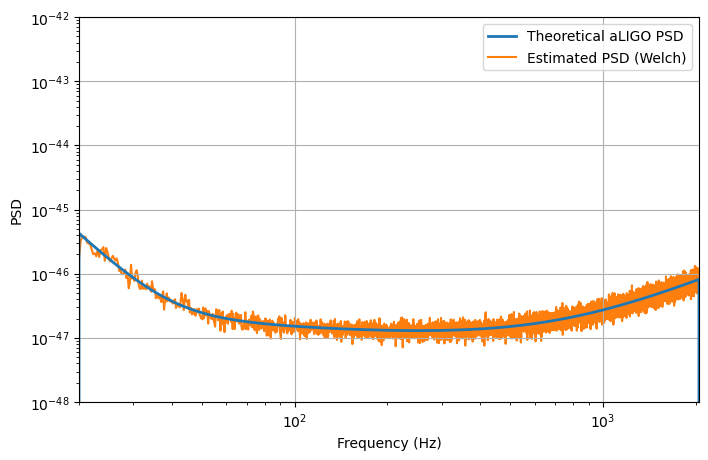

In [35]:
sample_rate = 4096
duration = 128
flow = 20.0

delta_t = 1.0 / sample_rate
delta_f = 1.0 / duration
flen = int(sample_rate / (2 * delta_f)) + 1

psd_theoretical = pycbc.psd.aLIGOZeroDetHighPower(flen, delta_f, flow)

# Generate noise
noise = pycbc.noise.noise_from_psd(duration * sample_rate, delta_t, psd_theoretical, seed=127)

# Estimate PSD using Welch's method
psd_estimated = noise.psd(segment_duration=4, avg_method='median')

plt.figure(figsize=(8, 5))
plt.loglog(psd_theoretical.sample_frequencies, psd_theoretical, label='Theoretical aLIGO PSD', linewidth=2)
plt.loglog(psd_estimated.sample_frequencies, psd_estimated, label='Estimated PSD (Welch)', zorder=-1)
plt.xlim(flow, sample_rate / 2)
plt.ylim(1e-48, 1e-42)
plt.xlabel('Frequency (Hz)')
plt.ylabel('PSD')
plt.legend()
plt.grid(True)
plt.show()


## Question

1. Play with `sample_rate` and `duration`, how does that affect the PSD?
2. Also try changing the `segment_duration`. What is happening?
 

# Adding glitch and computing PSD

In [33]:
def sine_gaussian(t, A, f0, t0, sigma):
    return A * np.sin(2*np.pi*f0*(t-t0)) \
    * np.exp(-0.5 * ((t - t0) / sigma)**2)


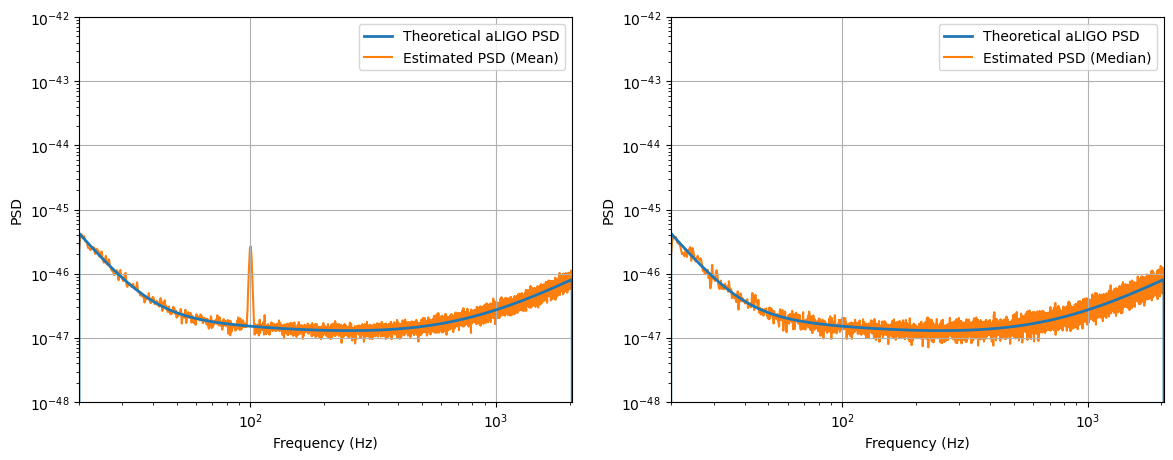

In [36]:
sample_rate = 4096
duration = 128
flow = 20.0

delta_t = 1.0 / sample_rate
delta_f = 1.0 / duration
flen = int(sample_rate / (2 * delta_f)) + 1

psd_theoretical = pycbc.psd.aLIGOZeroDetHighPower(flen, delta_f, flow)

# Generate noise
noise = pycbc.noise.noise_from_psd(duration * sample_rate, delta_t, psd_theoretical, seed=127)
glitchy_noise = noise + sine_gaussian(noise.sample_times, A=1e-21, f0=100, t0=2.5, sigma=0.1)

# PSD
psd_estimated_mean = glitchy_noise.psd(4.0, avg_method='mean')
psd_estimated_median = glitchy_noise.psd(4.0, avg_method='median')

fig, ax = plt.subplots(1, 2, figsize=(14, 5))
ax[0].loglog(psd_theoretical.sample_frequencies, psd_theoretical, label='Theoretical aLIGO PSD', linewidth=2)
ax[0].loglog(psd_estimated_mean.sample_frequencies, psd_estimated_mean, label='Estimated PSD (Mean)', zorder=-1)
ax[1].loglog(psd_theoretical.sample_frequencies, psd_theoretical, label='Theoretical aLIGO PSD', linewidth=2)
ax[1].loglog(psd_estimated_median.sample_frequencies, psd_estimated_median, label='Estimated PSD (Median)', zorder=-1)

for iax in ax:
    iax.set_xlim(flow, sample_rate / 2)
    iax.set_ylim(1e-48, 1e-42)
    iax.set_xlabel('Frequency (Hz)')
    iax.set_ylabel('PSD')
    iax.legend()
    iax.grid(True)

plt.show()


## Question:

3. Why did the glitch not appear in median but in mean averaging?